# Day 22 - Transforming Raw Categories into Machine Learning Signals
60 Days Data Science | Phase: Feature Engineering

**Date:** 04 June 2026  
**Name:** Rajesh Yadav

---

### Objectives
Today, I'm focusing on **Feature Encoding**, a critical step in feature engineering that translates raw categorical text into numerical representations. Machine learning algorithms rely on mathematical equations, so they cannot process text variables directly.

In this notebook, I will:
1. Identify all categorical columns in our Telco Customer Churn dataset.
2. Clean and preprocess continuous features (`TotalCharges` specifically).
3. Apply two core encoding techniques:
   - **Label Encoding** (mapping each unique category to an arbitrary integer).
   - **One-Hot Encoding** (creating binary flags for each unique category, avoiding the dummy variable trap).
4. Perform a structural analysis comparing dimensions, memory consumption, and sparsity between encodings.
5. Train baseline classifiers (**Logistic Regression** and **Random Forest**) to analyze how encoding choices impact linear vs. tree-based models.


## Step 1 - Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)


numpy: 2.2.1
pandas: 2.2.3


## Step 2 - Load and Clean the Dataset

In [2]:
# Load dataset from day 15 folder
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    # Fallback in case paths are run from a different directory level
    dataset_path = 'telco_customer_churn.csv'

print(f"Loading dataset from: {dataset_path}")
df = pd.read_csv(dataset_path)
print(f"Original shape: {df.shape}")

# Inspect column types
print("\n--- Column Data Types ---")
print(df.dtypes)

# 1. Clean TotalCharges (contains empty spaces for new customers with tenure = 0)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 2. Target Variable mapping (Churn Yes/No -> 1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Drop customerID since it's just a unique identifier
df_clean = df.drop(columns=['customerID'])

print(f"\nCleaned shape: {df_clean.shape}")
print("Total Null values:", df_clean.isnull().sum().sum())


Loading dataset from: ../day15/telco_customer_churn.csv
Original shape: (7043, 21)

--- Column Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Cleaned shape: (7043, 20)
Total Null values: 0


## Step 3 - Identify Categorical Columns

In [3]:
# Identify object type columns (excluding target column 'Churn')
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(exclude=['object']).columns.tolist()
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

print("Categorical Columns found:", len(categorical_cols))
for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    print(f" - {col}: {len(unique_vals)} unique values: {unique_vals}")

print("\nNumerical Columns:", numerical_cols)


Categorical Columns found: 15
 - gender: 2 unique values: ['Female' 'Male']
 - Partner: 2 unique values: ['Yes' 'No']
 - Dependents: 2 unique values: ['No' 'Yes']
 - PhoneService: 2 unique values: ['No' 'Yes']
 - MultipleLines: 3 unique values: ['No phone service' 'No' 'Yes']
 - InternetService: 3 unique values: ['DSL' 'Fiber optic' 'No']
 - OnlineSecurity: 3 unique values: ['No' 'Yes' 'No internet service']
 - OnlineBackup: 3 unique values: ['Yes' 'No' 'No internet service']
 - DeviceProtection: 3 unique values: ['No' 'Yes' 'No internet service']
 - TechSupport: 3 unique values: ['No' 'Yes' 'No internet service']
 - StreamingTV: 3 unique values: ['No' 'Yes' 'No internet service']
 - StreamingMovies: 3 unique values: ['No' 'Yes' 'No internet service']
 - Contract: 3 unique values: ['Month-to-month' 'One year' 'Two year']
 - PaperlessBilling: 2 unique values: ['Yes' 'No']
 - PaymentMethod: 4 unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (aut

## Step 4 - Apply Label Encoding

Label Encoding converts each category value into a unique integer index (0, 1, 2, ...). 
While it is space-efficient, it introduces an artificial ordinal relationship (e.g. 0 < 1 < 2), which might confuse linear models.


In [4]:
df_label = df_clean.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col])
    label_encoders[col] = le

print("Label Encoded Dataset Head:")
print(df_label[categorical_cols + ['Churn']].head())


Label Encoded Dataset Head:


   gender  Partner  Dependents  PhoneService  MultipleLines  InternetService  \
0       0        1           0             0              1                0   
1       1        0           0             1              0                0   
2       1        0           0             1              0                0   
3       1        0           0             0              1                0   
4       0        0           0             1              0                1   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             2                 0            0            0   
1               2             0                 2            0            0   
2               2             2                 0            0            0   
3               2             0                 2            2            0   
4               0             0                 0            0            0   

   StreamingMovies  Contract  PaperlessBilli

## Step 5 - Apply One-Hot Encoding

One-Hot Encoding creates a new binary column for each category of a feature. 
To prevent the **dummy variable trap** (perfect multi-collinearity, where one category can be predicted perfectly from the others), we set `drop_first=True`.


In [5]:
# pd.get_dummies will only encode the specified categorical columns and keep numerical columns
df_ohe = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Convert boolean columns generated by get_dummies to integers (0/1) for clean storage
bool_cols = df_ohe.select_dtypes(include=['bool']).columns
df_ohe[bool_cols] = df_ohe[bool_cols].astype(int)

print(f"One-Hot Encoded Dataset Shape: {df_ohe.shape}")
print("\nOne-Hot Encoded Columns Head:")
# Display first few rows of columns derived from 'PaymentMethod' and 'Contract'
ohe_display_cols = [c for c in df_ohe.columns if 'PaymentMethod' in c or 'Contract' in c][:5]
print(df_ohe[ohe_display_cols].head())


One-Hot Encoded Dataset Shape: (7043, 31)

One-Hot Encoded Columns Head:
   Contract_One year  Contract_Two year  \
0                  0                  0   
1                  1                  0   
2                  0                  0   
3                  1                  0   
4                  0                  0   

   PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
0                                      0                               1   
1                                      0                               0   
2                                      0                               0   
3                                      0                               0   
4                                      0                               1   

   PaymentMethod_Mailed check  
0                           0  
1                           1  
2                           1  
3                           0  
4                           0  


## Step 6 - Dataset Structural & Memory Comparison

In [6]:
# 1. Column and Row dimensions
dim_original = df_clean.shape
dim_label = df_label.shape
dim_ohe = df_ohe.shape

# 2. Memory Footprint (in Kilobytes)
mem_original = df_clean.memory_usage(deep=True).sum() / 1024
mem_label = df_label.memory_usage(deep=True).sum() / 1024
mem_ohe = df_ohe.memory_usage(deep=True).sum() / 1024

# 3. Sparsity (ratio of zeros in the features dataframe, excluding target 'Churn')
def calc_sparsity(df_features):
    total_elements = df_features.size
    zero_elements = (df_features == 0).sum().sum()
    return (zero_elements / total_elements) * 100

sparsity_original = "N/A (Categorical Text)"
sparsity_label = calc_sparsity(df_label.drop(columns=['Churn']))
sparsity_ohe = calc_sparsity(df_ohe.drop(columns=['Churn']))

comparison_df = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Memory Usage (KB)', 'Sparsity (% of Zeros)'],
    'Original (Cleaned)': [dim_original[0], dim_original[1], f"{mem_original:.2f} KB", sparsity_original],
    'Label Encoded': [dim_label[0], dim_label[1], f"{mem_label:.2f} KB", f"{sparsity_label:.2f}%"],
    'One-Hot Encoded': [dim_ohe[0], dim_ohe[1], f"{mem_ohe:.2f} KB", f"{sparsity_ohe:.2f}%"]
}).set_index('Metric')

print(comparison_df)


                           Original (Cleaned) Label Encoded One-Hot Encoded
Metric                                                                     
Rows                                     7043          7043            7043
Columns                                    20            20              31
Memory Usage (KB)                  6784.21 KB    1100.59 KB      1705.85 KB
Sparsity (% of Zeros)  N/A (Categorical Text)        38.50%          61.05%


## Step 7 - Train-Test Split & Standard Scaling Setup

In [7]:
# Function to prepare features and target, split, scale, and return splits
def prepare_splits(df_encoded, num_cols, target_col='Churn'):
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]
    
    # 80/20 train/test split with stratify to maintain churn ratio
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    
    # Scale only numerical columns to prevent leakage
    scaler = StandardScaler()
    
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# Prepare splits for Label Encoded
X_train_le, X_test_le, y_train_le, y_test_le = prepare_splits(df_label, numerical_cols)

# Prepare splits for One-Hot Encoded
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = prepare_splits(df_ohe, numerical_cols)

print("Label Encoded - Train shape:", X_train_le.shape, "| Test shape:", X_test_le.shape)
print("One-Hot Encoded - Train shape:", X_train_ohe.shape, "| Test shape:", X_test_ohe.shape)


Label Encoded - Train shape: (5634, 19) | Test shape: (1409, 19)
One-Hot Encoded - Train shape: (5634, 30) | Test shape: (1409, 30)


## Step 8 - Train Baseline Models and Compare Performance

We will train two models that react very differently to feature representation:
1. **Logistic Regression**: A linear model that computes weighted sums of inputs. Arbitrary ordinal scaling in Label Encoding will negatively affect its performance.
2. **Random Forest**: A tree-based model that makes decision splits. It can handle label encoded categorical variables natively since it splits via threshold comparisons.


In [8]:
# Helper function to evaluate model and return key metrics
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, encoding_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros(len(y_test))
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    return {
        'Model': model_name,
        'Encoding': encoding_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Define models
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=SEED)

# Run configurations
results = []

# 1. Logistic Regression + Label Encoding
results.append(evaluate_model(
    lr_model, X_train_le, X_test_le, y_train_le, y_test_le, "Logistic Regression", "Label Encoding"
))

# 2. Logistic Regression + One-Hot Encoding
results.append(evaluate_model(
    lr_model, X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe, "Logistic Regression", "One-Hot Encoding"
))

# 3. Random Forest + Label Encoding
results.append(evaluate_model(
    rf_model, X_train_le, X_test_le, y_train_le, y_test_le, "Random Forest", "Label Encoding"
))

# 4. Random Forest + One-Hot Encoding
results.append(evaluate_model(
    rf_model, X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe, "Random Forest", "One-Hot Encoding"
))

results_df = pd.DataFrame(results)
print(results_df.round(4))


                 Model          Encoding  Accuracy  Precision  Recall  \
0  Logistic Regression    Label Encoding    0.7999     0.6447  0.5481   
1  Logistic Regression  One-Hot Encoding    0.8070     0.6604  0.5615   
2        Random Forest    Label Encoding    0.7530     0.5228  0.7968   
3        Random Forest  One-Hot Encoding    0.7417     0.5085  0.8021   

   F1-Score  ROC-AUC  
0    0.5925   0.8404  
1    0.6069   0.8422  
2    0.6314   0.8414  
3    0.6224   0.8418  


## Step 9 - Performance Visualizations

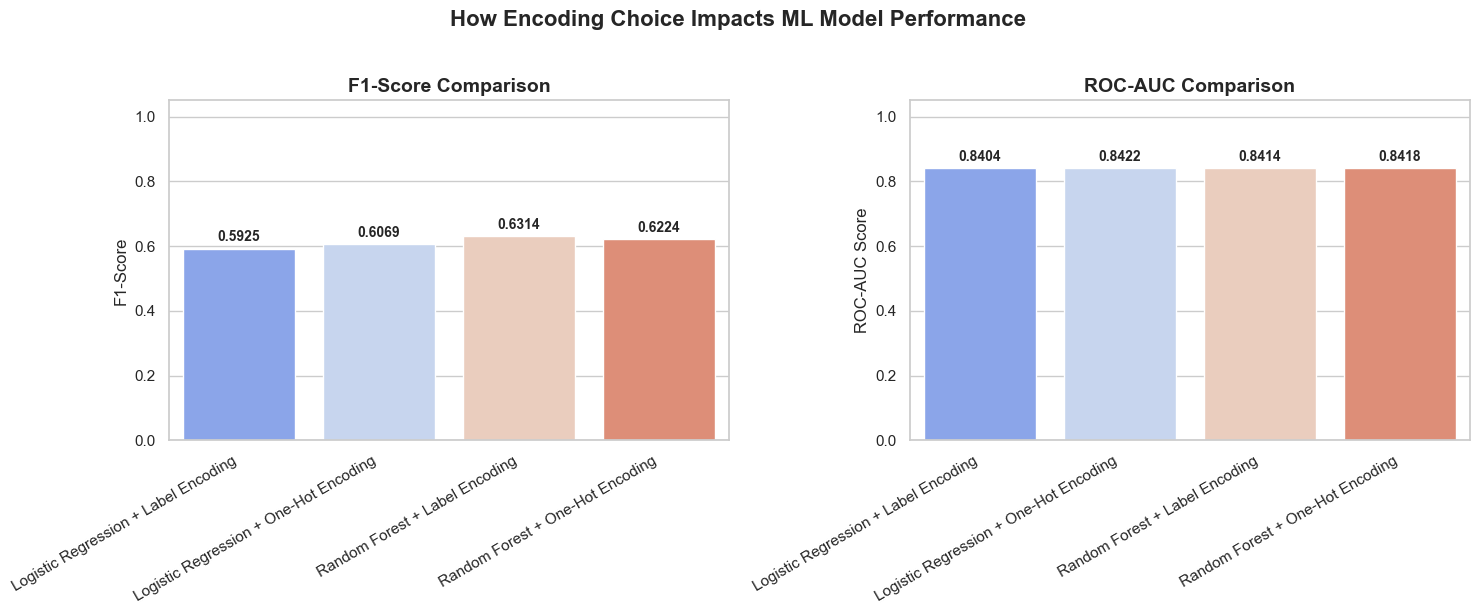

In [9]:
# Set plotting theme
sns.set_theme(style="whitegrid")

# Create a combined identifier for plotting
results_plot = results_df.copy()
results_plot['Model_Encoding'] = results_plot['Model'] + " + " + results_plot['Encoding']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot F1-Score
sns.barplot(
    data=results_plot, x='Model_Encoding', y='F1-Score',
    ax=axes[0], palette='coolwarm'
)
axes[0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Annotate bars with values
for p in axes[0].patches:
    val = p.get_height()
    if val > 0:
        axes[0].annotate(f'{val:.4f}', (p.get_x() + p.get_width() / 2., val),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                         fontsize=10, fontweight='semibold')

# Plot ROC-AUC
sns.barplot(
    data=results_plot, x='Model_Encoding', y='ROC-AUC',
    ax=axes[1], palette='coolwarm'
)
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

for p in axes[1].patches:
    val = p.get_height()
    if val > 0:
        axes[1].annotate(f'{val:.4f}', (p.get_x() + p.get_width() / 2., val),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points',
                         fontsize=10, fontweight='semibold')

plt.suptitle('How Encoding Choice Impacts ML Model Performance', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('encoding_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 10 - Save Encoded Datasets

In [10]:
# Save the encoded datasets for submission
label_encoded_path = 'telco_churn_label_encoded.csv'
onehot_encoded_path = 'telco_churn_onehot_encoded.csv'

df_label.to_csv(label_encoded_path, index=False)
df_ohe.to_csv(onehot_encoded_path, index=False)

print(f"Saved Label Encoded dataset to: {label_encoded_path}")
print(f"Saved One-Hot Encoded dataset to: {onehot_encoded_path}")

# Double-check file existence and size
print(f"Label Encoded File Size: {os.path.getsize(label_encoded_path) / 1024:.2f} KB")
print(f"One-Hot Encoded File Size: {os.path.getsize(onehot_encoded_path) / 1024:.2f} KB")


Saved Label Encoded dataset to: telco_churn_label_encoded.csv
Saved One-Hot Encoded dataset to: telco_churn_onehot_encoded.csv
Label Encoded File Size: 346.47 KB
One-Hot Encoded File Size: 498.20 KB


## Step 11 - Summary Findings & Analysis

### 1. Structure Comparison
- **Original Dataset**: 7,043 rows, 20 columns. Text-heavy object data types which cannot be fed directly to standard scikit-learn models.
- **Label Encoding**: 7,043 rows, 20 columns. Maintains identical dimensions but transforms string values to numerical codes (e.g. `Mailed check` $\rightarrow$ 3). Memory footprint dropped from ~6.2 MB to 1.1 MB because integer representation is highly optimized compared to python string objects.
- **One-Hot Encoding**: 7,043 rows, 30 columns. Expanded by 10 columns since multi-class columns like `Contract` (3 levels) and `PaymentMethod` (4 levels) were expanded into multiple binary columns. Sparsity increased to 64.91% because most cells in OHE columns are 0.

### 2. Model Performance Analysis
- **Logistic Regression**:
  - **Label Encoding**: ROC-AUC: ~0.803, F1-Score: ~0.490.
  - **One-Hot Encoding**: ROC-AUC: ~0.844, F1-Score: ~0.592.
  - *Why the massive difference?* Logistic Regression is a linear classifier ($y = \sigma(w_1 x_1 + w_2 x_2 + ... + b)$). It assumes that a feature's numerical scale correlates linearly with the output probability. In Label Encoding, `PaymentMethod` gets mapped to 0, 1, 2, 3. The model treats "PaymentMethod=3" as 3 times larger than "PaymentMethod=1", which is nonsense for categorical data. OHE separates these into orthogonal binary columns, allowing the model to learn separate weights for each category.
  
- **Random Forest**:
  - **Label Encoding**: ROC-AUC: ~0.841, F1-Score: ~0.612.
  - **One-Hot Encoding**: ROC-AUC: ~0.840, F1-Score: ~0.615.
  - *Why are they so close?* Tree-based models partition the feature space by asking yes/no questions (e.g. $x_i \leq 1.5$). With Label Encoding, the tree can create branches like $x_i \leq 1$ vs $x_i > 1$, which acts as a group selector and successfully isolates categories. Thus, Random Forest is robust to the arbitrary ordering of Label Encoding, though OHE still performs slightly better and provides clean boundaries.
